# Cyberbullying Dataset — Exploratory Data Analysis

Explore the tweet dataset and save plots for your portfolio. Training runs via `scripts/train.py`.

In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from cyberbullying.config import DATA_PATH, OUTPUTS_DIR
from cyberbullying.preprocessing import clean_text, to_binary_label

EDA_DIR = OUTPUTS_DIR / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv(DATA_PATH)
df["clean_text"] = df["tweet_text"].astype(str).map(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
df["binary_label"] = df["cyberbullying_type"].map(to_binary_label)
df["binary_name"] = df["binary_label"].map({0: "not_cyberbullying", 1: "cyberbullying"})
df["word_count"] = df["clean_text"].str.split().str.len()
df["char_count"] = df["clean_text"].str.len()

print(f"Rows: {len(df):,}")
print(f"Null tweets after cleaning: 0")
df.head()

Rows: 47,420
Null tweets after cleaning: 0


,tweet_text,cyberbullying_type,clean_text,binary_label,binary_name,word_count,char_count
0,"In other words #katandandre, your food was cra...",not_cyberbullying,in other words #katandandre your food was crap...,0,not_cyberbullying,9,59
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,why is #aussietv so white #mkr #theblock #imac...,0,not_cyberbullying,14,114
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,a classy whore or more red velvet cupcakes,0,not_cyberbullying,8,42
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,meh p thanks for the heads up but not too conc...,0,not_cyberbullying,17,87
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,this is an isis account pretending to be a kur...,0,not_cyberbullying,17,84


## Class distribution

Original labels are balanced (8k each). Binary mapping creates imbalance: most tweets are cyberbullying.

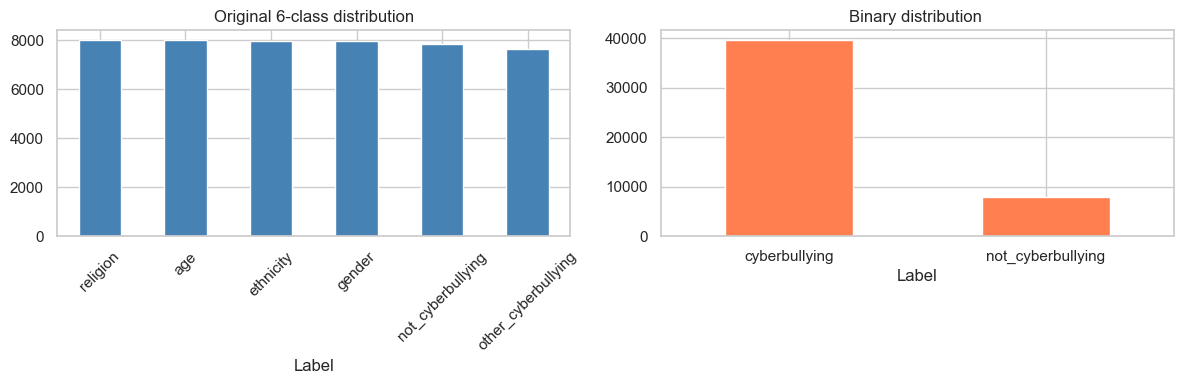

Binary ratio:
binary_name
cyberbullying        0.834
not_cyberbullying    0.166
Name: count, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

multiclass_counts = df["cyberbullying_type"].value_counts()
multiclass_counts.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Original 6-class distribution")
axes[0].set_xlabel("Label")
axes[0].tick_params(axis="x", rotation=45)

binary_counts = df["binary_name"].value_counts()
binary_counts.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Binary distribution ")
axes[1].set_xlabel("Label")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(EDA_DIR / "class_distribution.png", dpi=150)
plt.show()

print("Binary ratio:")
print((binary_counts / binary_counts.sum()).round(3))

## Text length

Most tweets are short. We pad/truncate to 128 tokens during training.

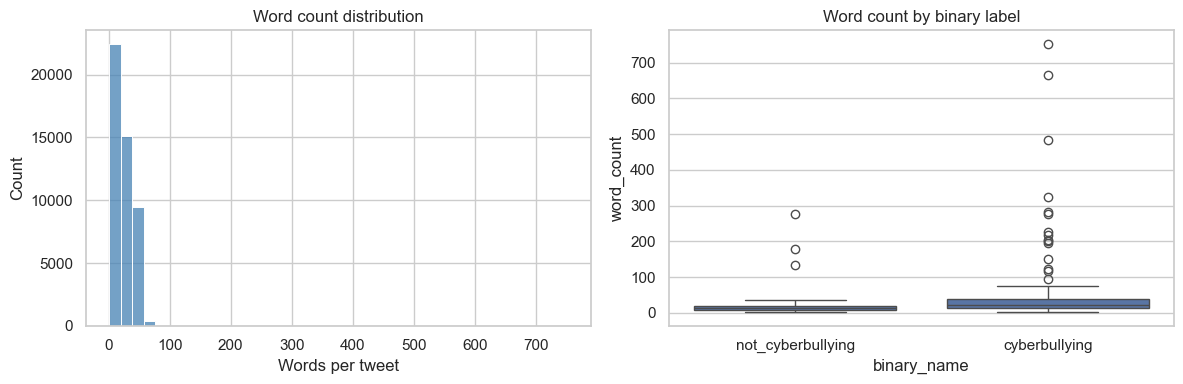

count    47420.000000
mean        23.878132
std         16.029338
min          1.000000
25%         13.000000
50%         20.000000
75%         33.000000
max        753.000000
Name: word_count, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["word_count"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Word count distribution")
axes[0].set_xlabel("Words per tweet")

sns.boxplot(data=df, x="binary_name", y="word_count", ax=axes[1])
axes[1].set_title("Word count by binary label")

plt.tight_layout()
plt.savefig(EDA_DIR / "text_length.png", dpi=150)
plt.show()

print(df["word_count"].describe())

## Sample tweets per class

Qualitative check — useful when explaining the problem in interviews.

In [6]:
for label in df["cyberbullying_type"].unique():
    print(f"\n=== {label} ===")
    samples = df[df["cyberbullying_type"] == label]["tweet_text"].head(3)
    for i, text in enumerate(samples, 1):
        print(f"{i}. {text[:120]}{'...' if len(text) > 120 else ''}")


=== not_cyberbullying ===
1. In other words #katandandre, your food was crapilicious! #mkr
2. Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc
3. @XochitlSuckkks a classy whore? Or more red velvet cupcakes?

=== gender ===
1. rape is real..zvasiyana nema jokes about being drunk or being gay or being lesbian...rape is not ones choice or wish..th...
2. You never saw any celebrity say anything like this for Obama: B Maher Incest Rape 'Joke' S Colbert Gay 'joke' K Griffin ...
3. @ManhattaKnight I mean he's gay, but he uses gendered slurs and makes rape jokes

=== religion ===
1. Sudeep, did she invite him though? No right? Why are you getting worded up? You're okay with Parvesh Verma cause he spea...
2. @discerningmumin Islam has never been a resistance to oppression. It has always been source of oppression to both believ...
3. Boy, your comment about Journalists wanting to keep churches closed is beneath you. As a Christi

## Top words (overall)

Simple unigram counts after cleaning — no heavy NLP libraries needed.

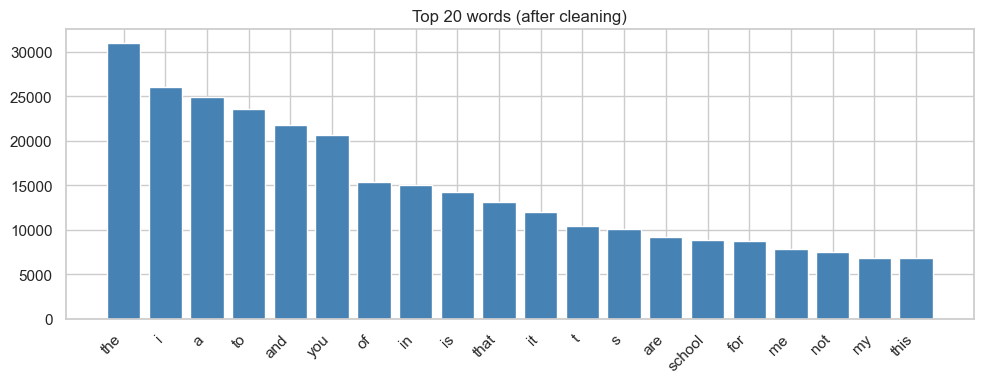

In [7]:
from collections import Counter

counter = Counter()
for text in df["clean_text"]:
    counter.update(text.split())

top_words = counter.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 4))
plt.bar(words, counts, color="steelblue")
plt.title("Top 20 words (after cleaning)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(EDA_DIR / "top_words.png", dpi=150)
plt.show()

## Next steps

Run the production pipeline:

```bash
python scripts/preprocess.py --task binary
python scripts/train.py --task binary
python scripts/evaluate.py --task binary
```